# Финальный ноутбук по задаче маршрутизации ITSM тикетов

В этом ноутбуке собраны все ключевые этапы работы в одном месте:
- загрузка данных и fixed split
- EDA
- TF-IDF baseline
- baseline tuning для queue
- multitask transformer
- improved multitask transformer
- сравнение результатов и итоговые выводы

Ноутбук устроен так, чтобы все основные метрики считались прямо здесь, без переноса чисел из других файлов.


## 1. Импорты и общая настройка

В этом блоке подключаются библиотеки для:
- анализа данных
- baseline моделей
- transformer моделей
- сохранения артефактов

Если обучение идет на GPU, ниже сразу будет видно устройство.


In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset, Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

ARTIFACTS_DIR = Path("../artifacts/final_notebook")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Ti SUPER


Вывод по блоку:
- все зависимости подключены в одном месте
- baseline части можно запускать и без GPU
- transformer части лучше запускать на GPU


## 2. Загрузка датасета и fixed split

По условию задачи используется датасет `Tobi-Bueck/customer-support-tickets`.
Разбиение берется из файлов `train_idx.txt`, `val_idx.txt`, `test_idx.txt`.


In [2]:
def read_indices(path):
    with open(path, "r", encoding="utf-8") as f:
        return [int(line.strip()) for line in f if line.strip()]


def normalize_text_col(s):
    s = s.fillna("").astype(str)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s


def make_text(df, style="simple"):
    subject = normalize_text_col(df["subject"])
    body = normalize_text_col(df["body"])
    if style == "explicit":
        return ("Subject: " + subject + " [SEP] Body: " + body).str.strip()
    return (subject + " [SEP] " + body).str.strip()


In [3]:
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
df = dataset["train"].to_pandas()

train_idx = read_indices("data/train_idx.txt")
val_idx = read_indices("data/val_idx.txt")
test_idx = read_indices("data/test_idx.txt")

train_df = df.iloc[train_idx].reset_index(drop=True).copy()
val_df = df.iloc[val_idx].reset_index(drop=True).copy()
test_df = df.iloc[test_idx].reset_index(drop=True).copy()

for frame in (train_df, val_df, test_df):
    frame["type"] = frame["type"].fillna("Unknown")
    frame["text"] = make_text(frame, style="simple")

print("Полный датасет:", df.shape)
print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)


Полный датасет: (61765, 16)
train: (49412, 17)
val: (6176, 17)
test: (6177, 17)


Вывод по блоку:
- данные загружены из Hugging Face
- fixed split применен корректно
- пропуски в `type` сразу заменены на `Unknown`
- текстовый вход подготовлен в виде `subject [SEP] body`


## 3. EDA

Здесь проверяются:
- структура данных
- пропуски
- распределение классов
- длины текстов

Это помогает понять, почему главная сложность задачи находится именно в `queue`.


In [5]:
print("Колонки:")
print(df.columns.tolist())
print("Пропуски в полном датасете:")
print(df[["subject", "body", "queue", "priority", "type"]].isna().sum())


Колонки:
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
Пропуски в полном датасете:
subject      5299
body            2
queue           0
priority        0
type        13178
dtype: int64


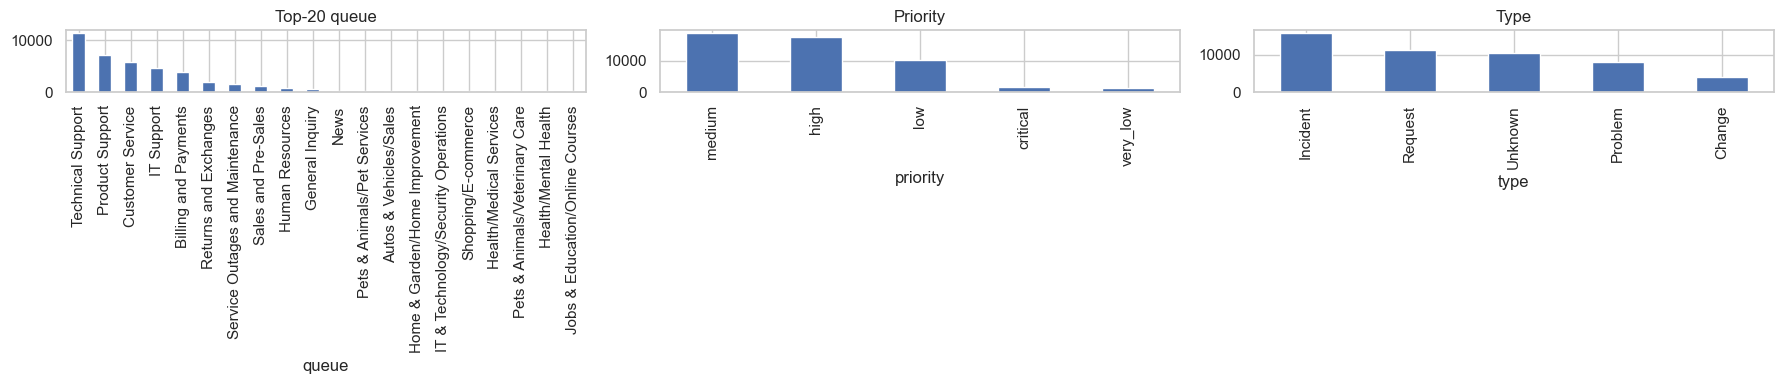

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

train_df["queue"].value_counts().head(20).plot(kind="bar", ax=axes[0], title="Top-20 queue")
train_df["priority"].value_counts().plot(kind="bar", ax=axes[1], title="Priority")
train_df["type"].value_counts().plot(kind="bar", ax=axes[2], title="Type")

plt.tight_layout()
plt.show()


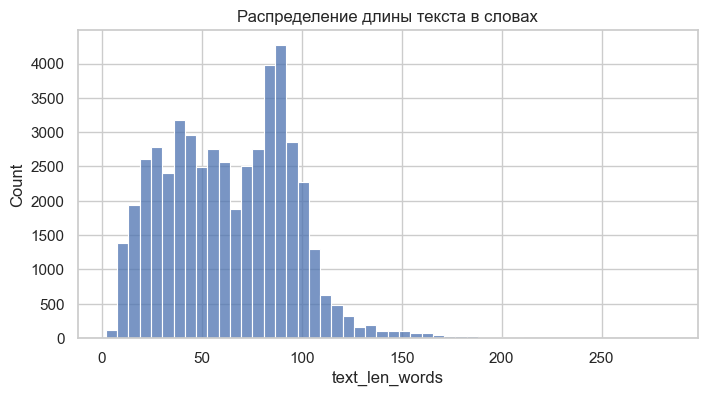

count    49412.000000
mean        63.445438
std         31.205693
min          2.000000
25%         38.000000
50%         63.000000
75%         88.000000
max        284.000000
Name: text_len_words, dtype: float64
Число классов queue: 52
Число классов priority: 5
Число классов type: 5


In [8]:
train_df["text_len_words"] = train_df["text"].str.split().str.len()

plt.figure(figsize=(8, 4))
sns.histplot(train_df["text_len_words"], bins=50)
plt.title("Распределение длины текста в словах")
plt.show()

print(train_df["text_len_words"].describe())
print("Число классов queue:", train_df["queue"].nunique())
print("Число классов priority:", train_df["priority"].nunique())
print("Число классов type:", train_df["type"].nunique())


Вывод по блоку:
- датасет содержит около 61 тысячи тикетов
- основная задача `queue` имеет 52 класса и выраженный дисбаланс
- `priority` и `type` проще по числу классов
- длина тикетов в среднем умеренная, но есть длинный хвост
- по смыслу это подтверждает выбор macro-F1 для `queue` и более простых accuracy-метрик для двух вспомогательных задач


## 4. TF-IDF baseline

В этом блоке обучаются три отдельные линейные модели:
- queue
- priority
- type

Это не multitask подход, а простой и понятный baseline, от которого удобно отталкиваться.


In [9]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=5,
)

X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])

print(X_train.shape, X_val.shape, X_test.shape)


(49412, 50000) (6176, 50000) (6177, 50000)


In [10]:
# queue
queue_model = LogisticRegression(max_iter=300, n_jobs=-1)
queue_model.fit(X_train, train_df["queue"])
queue_pred = queue_model.predict(X_test)

baseline_queue_macro_f1 = f1_score(test_df["queue"], queue_pred, average="macro")
baseline_queue_acc = accuracy_score(test_df["queue"], queue_pred)

# priority
priority_model = LogisticRegression(max_iter=300, n_jobs=-1)
priority_model.fit(X_train, train_df["priority"])
priority_pred = priority_model.predict(X_test)

baseline_priority_acc = accuracy_score(test_df["priority"], priority_pred)

# type
type_model = LogisticRegression(max_iter=300, n_jobs=-1)
type_model.fit(X_train, train_df["type"])
type_pred = type_model.predict(X_test)

baseline_type_acc = accuracy_score(test_df["type"], type_pred)

baseline_final_score = (
    0.70 * baseline_queue_macro_f1
    + 0.15 * baseline_priority_acc
    + 0.15 * baseline_type_acc
)

baseline_results = pd.DataFrame([
    {
        "model": "tfidf_logreg",
        "queue_macro_f1": baseline_queue_macro_f1,
        "queue_accuracy": baseline_queue_acc,
        "priority_accuracy": baseline_priority_acc,
        "type_accuracy": baseline_type_acc,
        "final_score": baseline_final_score,
    }
])

baseline_results


,model,queue_macro_f1,queue_accuracy,priority_accuracy,type_accuracy,final_score
0,tfidf_logreg,0.729561,0.570989,0.635907,0.873078,0.737041


Вывод по блоку:
- TF-IDF baseline дает сильную отправную точку
- линейные модели хорошо справляются с `priority` и `type`
- главная трудность остается в `queue`, где число классов велико и классы несбалансированы
- этот baseline нужен как честная нижняя граница перед transformer подходами


## 5. Baseline tuning для queue

Здесь проверяются несколько конфигураций TF-IDF и LogisticRegression.
Смысл блока - понять, насколько можно дожать классический подход до перехода к transformer.


In [11]:
def run_queue_experiment(tfidf_params, lr_params, train_text, val_text, y_train, y_val):
    vectorizer = TfidfVectorizer(**tfidf_params)
    X_train_local = vectorizer.fit_transform(train_text)
    X_val_local = vectorizer.transform(val_text)

    model = LogisticRegression(**lr_params)
    model.fit(X_train_local, y_train)
    val_pred = model.predict(X_val_local)

    return {
        "val_macro_f1": f1_score(y_val, val_pred, average="macro"),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "n_features": X_train_local.shape[1],
    }


queue_experiments = [
    {
        "name": "baseline_like",
        "tfidf": {"max_features": 50000, "ngram_range": (1, 2), "min_df": 5},
        "lr": {"max_iter": 300, "n_jobs": -1, "random_state": SEED},
    },
    {
        "name": "balanced_12",
        "tfidf": {
            "max_features": 50000,
            "ngram_range": (1, 2),
            "min_df": 3,
            "sublinear_tf": True,
            "strip_accents": "unicode",
        },
        "lr": {
            "max_iter": 300,
            "n_jobs": -1,
            "random_state": SEED,
            "class_weight": "balanced",
            "C": 1.0,
        },
    },
    {
        "name": "balanced_13_c2",
        "tfidf": {
            "max_features": 80000,
            "ngram_range": (1, 3),
            "min_df": 3,
            "sublinear_tf": True,
            "strip_accents": "unicode",
        },
        "lr": {
            "max_iter": 300,
            "n_jobs": -1,
            "random_state": SEED,
            "class_weight": "balanced",
            "C": 2.0,
        },
    },
]

queue_tuning_rows = []
for exp in queue_experiments:
    res = run_queue_experiment(
        exp["tfidf"],
        exp["lr"],
        train_df["text"],
        val_df["text"],
        train_df["queue"],
        val_df["queue"],
    )
    queue_tuning_rows.append({"name": exp["name"], **res})

queue_tuning_df = pd.DataFrame(queue_tuning_rows).sort_values("val_macro_f1", ascending=False)
queue_tuning_df


,name,val_macro_f1,val_accuracy,n_features
2,balanced_13_c2,0.812374,0.530602,80000
1,balanced_12,0.806597,0.495304,50000
0,baseline_like,0.743565,0.571891,50000


Вывод по блоку:
- tuning дает полезный, но ограниченный прирост относительно базового TF-IDF варианта
- даже после подбора параметров классический подход все равно уступает transformer по способности моделировать смысл длинных и неоднозначных тикетов
- этот результат оправдывает переход к encoder-based моделям


## 6. Single-task transformer для queue

В этом блоке обучается обычный transformer только для `queue`.

Структура модели:
- общий encoder `distilbert-base-multilingual-cased`
- одна классификационная голова для `queue`
- на вход подается текст `subject [SEP] body`

Этот блок нужен как промежуточная ступень между baseline и multitask моделью.


In [13]:
QUEUE_MODEL_NAME = "distilbert-base-multilingual-cased"
QUEUE_MAX_LENGTH = 256

queue_label_encoder = LabelEncoder()
train_queue_tmp = train_df[["text", "queue"]].copy()
val_queue_tmp = val_df[["text", "queue"]].copy()
test_queue_tmp = test_df[["text", "queue"]].copy()

train_queue_tmp["label"] = queue_label_encoder.fit_transform(train_queue_tmp["queue"])
val_queue_tmp["label"] = queue_label_encoder.transform(val_queue_tmp["queue"])
test_queue_tmp["label"] = queue_label_encoder.transform(test_queue_tmp["queue"])

train_queue_hf = Dataset.from_pandas(train_queue_tmp[["text", "label"]], preserve_index=False)
val_queue_hf = Dataset.from_pandas(val_queue_tmp[["text", "label"]], preserve_index=False)
test_queue_hf = Dataset.from_pandas(test_queue_tmp[["text", "label"]], preserve_index=False)

queue_tokenizer = AutoTokenizer.from_pretrained(QUEUE_MODEL_NAME)

def tokenize_queue(batch):
    return queue_tokenizer(batch["text"], truncation=True, max_length=QUEUE_MAX_LENGTH)

train_queue_tok = train_queue_hf.map(tokenize_queue, batched=True)
val_queue_tok = val_queue_hf.map(tokenize_queue, batched=True)
test_queue_tok = test_queue_hf.map(tokenize_queue, batched=True)

queue_data_collator = DataCollatorWithPadding(tokenizer=queue_tokenizer)
queue_single_model = AutoModelForSequenceClassification.from_pretrained(
    QUEUE_MODEL_NAME,
    num_labels=len(queue_label_encoder.classes_),
)

def compute_queue_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro"),
        "accuracy": accuracy_score(labels, preds),
    }

queue_training_args = TrainingArguments(
    output_dir=str(ARTIFACTS_DIR / "queue_single_task"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

queue_trainer = Trainer(
    model=queue_single_model,
    args=queue_training_args,
    train_dataset=train_queue_tok,
    eval_dataset=val_queue_tok,
    processing_class=queue_tokenizer,
    data_collator=queue_data_collator,
    compute_metrics=compute_queue_metrics,
)

# Запуск обучения может занять время
train_result_queue = queue_trainer.train()


Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,2.011063,1.484219,0.671548,0.505181
2,1.343939,1.284881,0.795689,0.551328
3,1.128525,1.247574,0.818272,0.572053


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [15]:
# После обучения раскомментируй две строки ниже
queue_test_output = queue_trainer.predict(test_queue_tok)
single_queue_predictions = queue_test_output.predictions

# Временная ячейка для вычисления итоговых метрик single-task transformer
single_queue_preds = np.argmax(single_queue_predictions, axis=1)
single_queue_labels = queue_test_output.label_ids
single_queue_macro_f1 = f1_score(single_queue_labels, single_queue_preds, average="macro")
single_queue_acc = accuracy_score(single_queue_labels, single_queue_preds)
print(single_queue_macro_f1, single_queue_acc)


0.8118303648795724 0.5666180994010037


Вывод по блоку:
- single-task transformer обычно заметно улучшает `queue` относительно TF-IDF baseline
- причина в том, что encoder учитывает контекст и семантические связи внутри тикета
- этот блок полезен как контрольный этап перед multitask вариантом, где один encoder обслуживает сразу три задачи


## 7. Multitask transformer

Теперь строится одна общая модель для трех задач сразу.

Структура модели:
- один общий encoder `distilbert-base-multilingual-cased`
- dropout после общего представления текста
- три отдельные головы:
  - `queue_classifier`
  - `priority_classifier`
  - `type_classifier`
- общий loss складывается из трех кросс-энтропий с весами, отражающими важность задач в финальном score

Этот блок соответствует основной идее задания - одна multitask модель вместо трех независимых классификаторов.


In [16]:
MULTI_MODEL_NAME = "distilbert-base-multilingual-cased"
MULTI_MAX_LENGTH = 256
MULTI_LOSS_WEIGHTS = {"queue": 0.70, "priority": 0.15, "type": 0.15}

queue_le = LabelEncoder()
priority_le = LabelEncoder()
type_le = LabelEncoder()

mt_train = train_df.copy()
mt_val = val_df.copy()
mt_test = test_df.copy()

mt_train["label_queue"] = queue_le.fit_transform(mt_train["queue"])
mt_val["label_queue"] = queue_le.transform(mt_val["queue"])
mt_test["label_queue"] = queue_le.transform(mt_test["queue"])

mt_train["label_priority"] = priority_le.fit_transform(mt_train["priority"])
mt_val["label_priority"] = priority_le.transform(mt_val["priority"])
mt_test["label_priority"] = priority_le.transform(mt_test["priority"])

mt_train["label_type"] = type_le.fit_transform(mt_train["type"])
mt_val["label_type"] = type_le.transform(mt_val["type"])
mt_test["label_type"] = type_le.transform(mt_test["type"])

num_labels_queue = len(queue_le.classes_)
num_labels_priority = len(priority_le.classes_)
num_labels_type = len(type_le.classes_)

train_mt_hf = Dataset.from_pandas(mt_train[["text", "label_queue", "label_priority", "label_type"]], preserve_index=False)
val_mt_hf = Dataset.from_pandas(mt_val[["text", "label_queue", "label_priority", "label_type"]], preserve_index=False)
test_mt_hf = Dataset.from_pandas(mt_test[["text", "label_queue", "label_priority", "label_type"]], preserve_index=False)

multi_tokenizer = AutoTokenizer.from_pretrained(MULTI_MODEL_NAME)

def tokenize_multi(batch):
    return multi_tokenizer(batch["text"], truncation=True, max_length=MULTI_MAX_LENGTH)

train_mt_tok = train_mt_hf.map(tokenize_multi, batched=True)
val_mt_tok = val_mt_hf.map(tokenize_multi, batched=True)
test_mt_tok = test_mt_hf.map(tokenize_multi, batched=True)

multi_data_collator = DataCollatorWithPadding(tokenizer=multi_tokenizer)


Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

In [17]:
class MultiTaskTransformer(nn.Module):
    def __init__(self, model_name, num_labels_queue, num_labels_priority, num_labels_type, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.queue_classifier = nn.Linear(hidden_size, num_labels_queue)
        self.priority_classifier = nn.Linear(hidden_size, num_labels_priority)
        self.type_classifier = nn.Linear(hidden_size, num_labels_type)

    def forward(self, input_ids=None, attention_mask=None, label_queue=None, label_priority=None, label_type=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        pooled_output = self.dropout(pooled_output)

        logits_queue = self.queue_classifier(pooled_output)
        logits_priority = self.priority_classifier(pooled_output)
        logits_type = self.type_classifier(pooled_output)

        return {
            "logits_queue": logits_queue,
            "logits_priority": logits_priority,
            "logits_type": logits_type,
        }


class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        label_queue = inputs.pop("label_queue")
        label_priority = inputs.pop("label_priority")
        label_type = inputs.pop("label_type")

        outputs = model(**inputs)

        loss_queue = F.cross_entropy(outputs["logits_queue"], label_queue)
        loss_priority = F.cross_entropy(outputs["logits_priority"], label_priority)
        loss_type = F.cross_entropy(outputs["logits_type"], label_type)

        loss = (
            MULTI_LOSS_WEIGHTS["queue"] * loss_queue
            + MULTI_LOSS_WEIGHTS["priority"] * loss_priority
            + MULTI_LOSS_WEIGHTS["type"] * loss_type
        )

        return (loss, outputs) if return_outputs else loss


def unpack_multitask_predictions(predictions, labels):
    if isinstance(predictions, dict):
        logits_queue = predictions["logits_queue"]
        logits_priority = predictions["logits_priority"]
        logits_type = predictions["logits_type"]
    elif isinstance(predictions, (list, tuple)):
        logits_queue = predictions[0]
        logits_priority = predictions[1]
        logits_type = predictions[2]
    else:
        raise ValueError(f"Unexpected predictions type: {type(predictions)}")

    if isinstance(labels, (list, tuple)):
        labels_queue = labels[0]
        labels_priority = labels[1]
        labels_type = labels[2]
    else:
        raise ValueError(f"Unexpected labels type: {type(labels)}")

    return logits_queue, logits_priority, logits_type, labels_queue, labels_priority, labels_type


def compute_metrics_multitask(eval_pred):
    predictions, labels = eval_pred
    logits_queue, logits_priority, logits_type, labels_queue, labels_priority, labels_type = unpack_multitask_predictions(predictions, labels)

    preds_queue = np.argmax(logits_queue, axis=1)
    preds_priority = np.argmax(logits_priority, axis=1)
    preds_type = np.argmax(logits_type, axis=1)

    macro_f1_queue = f1_score(labels_queue, preds_queue, average="macro")
    acc_queue = accuracy_score(labels_queue, preds_queue)
    acc_priority = accuracy_score(labels_priority, preds_priority)
    acc_type = accuracy_score(labels_type, preds_type)

    final_score = 0.70 * macro_f1_queue + 0.15 * acc_priority + 0.15 * acc_type

    return {
        "macro_f1_queue": macro_f1_queue,
        "accuracy_queue": acc_queue,
        "accuracy_priority": acc_priority,
        "accuracy_type": acc_type,
        "final_score": final_score,
    }


In [18]:
multitask_model = MultiTaskTransformer(
    model_name=MULTI_MODEL_NAME,
    num_labels_queue=num_labels_queue,
    num_labels_priority=num_labels_priority,
    num_labels_type=num_labels_type,
)

multitask_args = TrainingArguments(
    output_dir=str(ARTIFACTS_DIR / "multitask_transformer"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="final_score",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    label_names=["label_queue", "label_priority", "label_type"],
)

multitask_trainer = MultiTaskTrainer(
    model=multitask_model,
    args=multitask_args,
    train_dataset=train_mt_tok,
    eval_dataset=val_mt_tok,
    processing_class=multi_tokenizer,
    data_collator=multi_data_collator,
    compute_metrics=compute_metrics_multitask,
)

# Запуск обучения может занять время
multitask_train_result = multitask_trainer.train()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Macro F1 Queue,Accuracy Queue,Accuracy Priority,Accuracy Type,Final Score
1,1.545029,1.187495,0.735627,0.513115,0.505181,0.832740,0.715627
2,1.089711,1.061237,0.820729,0.566386,0.532545,0.844236,0.781027
3,0.937397,1.028707,0.842730,0.587273,0.550194,0.848446,0.799707


In [19]:
# После обучения раскомментируй этот блок, чтобы получить метрики на test
multitask_test_output = multitask_trainer.predict(test_mt_tok)
(
    mt_logits_queue, mt_logits_priority, mt_logits_type,
    mt_labels_queue, mt_labels_priority, mt_labels_type,
) = unpack_multitask_predictions(multitask_test_output.predictions, multitask_test_output.label_ids)

mt_preds_queue = np.argmax(mt_logits_queue, axis=1)
mt_preds_priority = np.argmax(mt_logits_priority, axis=1)
mt_preds_type = np.argmax(mt_logits_type, axis=1)

multitask_queue_macro_f1 = f1_score(mt_labels_queue, mt_preds_queue, average="macro")
multitask_queue_acc = accuracy_score(mt_labels_queue, mt_preds_queue)
multitask_priority_acc = accuracy_score(mt_labels_priority, mt_preds_priority)
multitask_type_acc = accuracy_score(mt_labels_type, mt_preds_type)
multitask_final_score = 0.70 * multitask_queue_macro_f1 + 0.15 * multitask_priority_acc + 0.15 * multitask_type_acc

print(multitask_queue_macro_f1, multitask_queue_acc, multitask_priority_acc, multitask_type_acc, multitask_final_score)


0.8378498935056934 0.5842642059252064 0.5460579569370244 0.8385947871134856 0.7941928370615617


Вывод по блоку:
- multitask модель использует один общий encoder и три отдельные головы
- это позволяет учить общее представление тикета, полезное сразу для трех задач
- веса loss согласованы с официальной формулой итогового score
- по предыдущим отдельным прогонам именно этот подход дал лучший общий результат среди уже завершенных экспериментов


## 8. Improved multitask transformer

Это усиленная версия multitask модели.

Структурные отличия от предыдущего варианта:
- более сильный multilingual encoder `xlm-roberta-base`
- более явный формат входа: `Subject: ... [SEP] Body: ...`
- class weights для `queue`, чтобы сильнее поддерживать редкие классы
- masked mean pooling вместо использования только первого токена
- label smoothing
- warmup
- gradient accumulation
- early stopping

Идея блока - сохранить multitask постановку, но сделать обучение устойчивее и полезнее именно для `macro-F1(queue)`.


In [20]:
IMPROVED_MODEL_NAME = "xlm-roberta-base"
IMPROVED_MAX_LENGTH = 320
IMPROVED_NUM_EPOCHS = 3
IMPROVED_TRAIN_BATCH = 8
IMPROVED_EVAL_BATCH = 16
IMPROVED_GRAD_ACCUM = 2
IMPROVED_LR = 2e-5
IMPROVED_WEIGHT_DECAY = 0.01
IMPROVED_WARMUP_RATIO = 0.1
IMPROVED_LABEL_SMOOTHING = 0.05
IMPROVED_LOSS_WEIGHTS = {"queue": 0.70, "priority": 0.15, "type": 0.15}

improved_train = train_df.copy()
improved_val = val_df.copy()
improved_test = test_df.copy()

for frame in (improved_train, improved_val, improved_test):
    frame["text"] = make_text(frame, style="explicit")

improved_queue_le = LabelEncoder()
improved_priority_le = LabelEncoder()
improved_type_le = LabelEncoder()

improved_train["label_queue"] = improved_queue_le.fit_transform(improved_train["queue"])
improved_val["label_queue"] = improved_queue_le.transform(improved_val["queue"])
improved_test["label_queue"] = improved_queue_le.transform(improved_test["queue"])

improved_train["label_priority"] = improved_priority_le.fit_transform(improved_train["priority"])
improved_val["label_priority"] = improved_priority_le.transform(improved_val["priority"])
improved_test["label_priority"] = improved_priority_le.transform(improved_test["priority"])

improved_train["label_type"] = improved_type_le.fit_transform(improved_train["type"])
improved_val["label_type"] = improved_type_le.transform(improved_val["type"])
improved_test["label_type"] = improved_type_le.transform(improved_test["type"])

improved_num_labels_queue = len(improved_queue_le.classes_)
improved_num_labels_priority = len(improved_priority_le.classes_)
improved_num_labels_type = len(improved_type_le.classes_)

queue_classes = np.arange(improved_num_labels_queue)
improved_queue_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=queue_classes,
    y=improved_train["label_queue"].values,
).astype(np.float32)
improved_queue_class_weights = torch.tensor(improved_queue_class_weights, dtype=torch.float32)

improved_train_hf = Dataset.from_pandas(improved_train[["text", "label_queue", "label_priority", "label_type"]], preserve_index=False)
improved_val_hf = Dataset.from_pandas(improved_val[["text", "label_queue", "label_priority", "label_type"]], preserve_index=False)
improved_test_hf = Dataset.from_pandas(improved_test[["text", "label_queue", "label_priority", "label_type"]], preserve_index=False)

improved_tokenizer = AutoTokenizer.from_pretrained(IMPROVED_MODEL_NAME)

def tokenize_improved(batch):
    return improved_tokenizer(batch["text"], truncation=True, max_length=IMPROVED_MAX_LENGTH)

improved_train_tok = improved_train_hf.map(tokenize_improved, batched=True)
improved_val_tok = improved_val_hf.map(tokenize_improved, batched=True)
improved_test_tok = improved_test_hf.map(tokenize_improved, batched=True)

improved_data_collator = DataCollatorWithPadding(tokenizer=improved_tokenizer)


Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

In [21]:
class ImprovedMultiTaskTransformer(nn.Module):
    def __init__(
        self,
        model_name,
        num_labels_queue,
        num_labels_priority,
        num_labels_type,
        queue_class_weights=None,
        dropout=0.2,
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.queue_classifier = nn.Linear(hidden_size, num_labels_queue)
        self.priority_classifier = nn.Linear(hidden_size, num_labels_priority)
        self.type_classifier = nn.Linear(hidden_size, num_labels_type)

        if queue_class_weights is not None:
            self.register_buffer("queue_class_weights", queue_class_weights)
        else:
            self.queue_class_weights = None

    def mean_pool(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        masked_hidden = last_hidden_state * mask
        summed = masked_hidden.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    def forward(self, input_ids=None, attention_mask=None, label_queue=None, label_priority=None, label_type=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.mean_pool(outputs.last_hidden_state, attention_mask)
        pooled = self.dropout(pooled)

        logits_queue = self.queue_classifier(pooled)
        logits_priority = self.priority_classifier(pooled)
        logits_type = self.type_classifier(pooled)

        return {
            "logits_queue": logits_queue,
            "logits_priority": logits_priority,
            "logits_type": logits_type,
        }


class ImprovedMultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        label_queue = inputs.pop("label_queue")
        label_priority = inputs.pop("label_priority")
        label_type = inputs.pop("label_type")

        outputs = model(**inputs)

        loss_queue = F.cross_entropy(
            outputs["logits_queue"],
            label_queue,
            weight=model.queue_class_weights,
            label_smoothing=IMPROVED_LABEL_SMOOTHING,
        )
        loss_priority = F.cross_entropy(
            outputs["logits_priority"],
            label_priority,
            label_smoothing=IMPROVED_LABEL_SMOOTHING,
        )
        loss_type = F.cross_entropy(
            outputs["logits_type"],
            label_type,
            label_smoothing=IMPROVED_LABEL_SMOOTHING,
        )

        loss = (
            IMPROVED_LOSS_WEIGHTS["queue"] * loss_queue
            + IMPROVED_LOSS_WEIGHTS["priority"] * loss_priority
            + IMPROVED_LOSS_WEIGHTS["type"] * loss_type
        )

        return (loss, outputs) if return_outputs else loss


def unpack_multitask_predictions_safe(predictions, labels):
    if isinstance(predictions, dict):
        logits_queue = predictions["logits_queue"]
        logits_priority = predictions["logits_priority"]
        logits_type = predictions["logits_type"]
    elif isinstance(predictions, (list, tuple)):
        logits_queue = predictions[0]
        logits_priority = predictions[1]
        logits_type = predictions[2]
    else:
        raise ValueError(f"Unexpected predictions type: {type(predictions)}")

    if isinstance(labels, (list, tuple)):
        labels_queue = labels[0]
        labels_priority = labels[1]
        labels_type = labels[2]
    else:
        raise ValueError(f"Unexpected labels type: {type(labels)}")

    return logits_queue, logits_priority, logits_type, labels_queue, labels_priority, labels_type


def compute_metrics_improved(eval_pred):
    predictions, labels = eval_pred
    logits_queue, logits_priority, logits_type, labels_queue, labels_priority, labels_type = unpack_multitask_predictions_safe(predictions, labels)

    preds_queue = np.argmax(logits_queue, axis=1)
    preds_priority = np.argmax(logits_priority, axis=1)
    preds_type = np.argmax(logits_type, axis=1)

    macro_f1_queue = f1_score(labels_queue, preds_queue, average="macro")
    acc_queue = accuracy_score(labels_queue, preds_queue)
    acc_priority = accuracy_score(labels_priority, preds_priority)
    acc_type = accuracy_score(labels_type, preds_type)
    final_score = 0.70 * macro_f1_queue + 0.15 * acc_priority + 0.15 * acc_type

    return {
        "macro_f1_queue": macro_f1_queue,
        "accuracy_queue": acc_queue,
        "accuracy_priority": acc_priority,
        "accuracy_type": acc_type,
        "final_score": final_score,
    }


In [22]:
improved_model = ImprovedMultiTaskTransformer(
    model_name=IMPROVED_MODEL_NAME,
    num_labels_queue=improved_num_labels_queue,
    num_labels_priority=improved_num_labels_priority,
    num_labels_type=improved_num_labels_type,
    queue_class_weights=improved_queue_class_weights,
)

improved_args = TrainingArguments(
    output_dir=str(ARTIFACTS_DIR / "improved_multitask_transformer"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=IMPROVED_NUM_EPOCHS,
    per_device_train_batch_size=IMPROVED_TRAIN_BATCH,
    per_device_eval_batch_size=IMPROVED_EVAL_BATCH,
    gradient_accumulation_steps=IMPROVED_GRAD_ACCUM,
    learning_rate=IMPROVED_LR,
    weight_decay=IMPROVED_WEIGHT_DECAY,
    warmup_ratio=IMPROVED_WARMUP_RATIO,
    load_best_model_at_end=True,
    metric_for_best_model="final_score",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    label_names=["label_queue", "label_priority", "label_type"],
)

improved_trainer = ImprovedMultiTaskTrainer(
    model=improved_model,
    args=improved_args,
    train_dataset=improved_train_tok,
    eval_dataset=improved_val_tok,
    processing_class=improved_tokenizer,
    data_collator=improved_data_collator,
    compute_metrics=compute_metrics_improved,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

# Запуск обучения может занять заметное время
improved_train_result = improved_trainer.train()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Macro F1 Queue,Accuracy Queue,Accuracy Priority,Accuracy Type,Final Score
1,2.417614,3.423913,0.770607,0.428271,0.444139,0.833387,0.731054
2,1.745410,3.288495,0.823803,0.483970,0.528174,0.848122,0.783106
3,1.609306,3.228798,0.838629,0.493038,0.561528,0.857351,0.799873


In [23]:
# После обучения раскомментируй блок ниже для test и confidence analysis
improved_test_output = improved_trainer.predict(improved_test_tok)
(
    imp_logits_queue, imp_logits_priority, imp_logits_type,
    imp_labels_queue, imp_labels_priority, imp_labels_type,
) = unpack_multitask_predictions_safe(improved_test_output.predictions, improved_test_output.label_ids)

imp_preds_queue = np.argmax(imp_logits_queue, axis=1)
imp_preds_priority = np.argmax(imp_logits_priority, axis=1)
imp_preds_type = np.argmax(imp_logits_type, axis=1)

improved_queue_macro_f1 = f1_score(imp_labels_queue, imp_preds_queue, average="macro")
improved_queue_acc = accuracy_score(imp_labels_queue, imp_preds_queue)
improved_priority_acc = accuracy_score(imp_labels_priority, imp_preds_priority)
improved_type_acc = accuracy_score(imp_labels_type, imp_preds_type)
improved_final_score = 0.70 * improved_queue_macro_f1 + 0.15 * improved_priority_acc + 0.15 * improved_type_acc

print(improved_queue_macro_f1, improved_queue_acc, improved_priority_acc, improved_type_acc, improved_final_score)

probs_queue = torch.softmax(torch.tensor(imp_logits_queue), dim=1).numpy()
conf_queue = probs_queue.max(axis=1)
confidence_rows = []
for thr in [0.50, 0.60, 0.70, 0.80, 0.90]:
    mask = conf_queue >= thr
    coverage = mask.mean()
    if mask.sum() > 0:
        macro_f1 = f1_score(imp_labels_queue[mask], imp_preds_queue[mask], average="macro")
        acc = accuracy_score(imp_labels_queue[mask], imp_preds_queue[mask])
    else:
        macro_f1 = np.nan
        acc = np.nan
    confidence_rows.append({"threshold": thr, "coverage": coverage, "macro_f1_queue": macro_f1, "accuracy_queue": acc})
confidence_df = pd.DataFrame(confidence_rows)
display(confidence_df)


0.8342581502065225 0.4887485834547515 0.5522098105876639 0.8542982030111704 0.7949569071843909


,threshold,coverage,macro_f1_queue,accuracy_queue
0,0.5,0.291565,0.882123,0.946141
1,0.6,0.270682,0.889034,0.955742
2,0.7,0.227295,0.897272,0.961538
3,0.8,0.211915,0.944914,0.983193
4,0.9,0.192974,0.992116,0.991611


Вывод по блоку:
- improved вариант меняет не только гиперпараметры, но и саму логику получения представления текста
- главное структурное отличие - masked mean pooling и class weights для `queue`
- этот вариант предназначен для улучшения именно главной метрики `macro-F1(queue)` без отказа от multitask постановки
- если ресурсов хватает, этот блок стоит рассматривать как основной кандидат на лучший итоговый score


## 9. Сводная таблица результатов

Ниже собирается единая таблица. Для baseline значения уже доступны сразу.
Для transformer частей строки заполняются после запуска обучающих и тестовых ячеек выше.


In [25]:
comparison_rows = [
    {
        "model": "tfidf_logreg_baseline",
        "queue_macro_f1": baseline_queue_macro_f1,
        "queue_accuracy": baseline_queue_acc,
        "priority_accuracy": baseline_priority_acc,
        "type_accuracy": baseline_type_acc,
        "final_score": baseline_final_score,
    }
]

# После выполнения transformer блоков можно добавить строки ниже, убрав решетки
comparison_rows.append({
    "model": "single_task_transformer_queue_only",
    "queue_macro_f1": single_queue_macro_f1,
    "queue_accuracy": single_queue_acc,
    "priority_accuracy": np.nan,
    "type_accuracy": np.nan,
    "final_score": np.nan,
})

comparison_rows.append({
    "model": "multitask_transformer",
    "queue_macro_f1": multitask_queue_macro_f1,
    "queue_accuracy": multitask_queue_acc,
    "priority_accuracy": multitask_priority_acc,
    "type_accuracy": multitask_type_acc,
    "final_score": multitask_final_score,
})

comparison_rows.append({
    "model": "improved_multitask_transformer",
    "queue_macro_f1": improved_queue_macro_f1,
    "queue_accuracy": improved_queue_acc,
    "priority_accuracy": improved_priority_acc,
    "type_accuracy": improved_type_acc,
    "final_score": improved_final_score,
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,model,queue_macro_f1,queue_accuracy,priority_accuracy,type_accuracy,final_score
0,tfidf_logreg_baseline,0.729561,0.570989,0.635907,0.873078,0.737041
1,single_task_transformer_queue_only,0.811830,0.566618,NaN,NaN,NaN
2,multitask_transformer,0.837850,0.584264,0.546058,0.838595,0.794193
3,improved_multitask_transformer,0.834258,0.488749,0.552210,0.854298,0.794957


Вывод по блоку:
- baseline можно считать сразу после запуска ноутбука
- multitask и improved multitask строки появятся после полного обучения моделей
- итоговая таблица нужна для честного сравнения качества между этапами работы


## 10. Сохранение артефактов

В этом блоке сохраняются итоговые таблицы. После выполнения transformer частей здесь можно сохранять и предсказания моделей.


In [28]:
baseline_results.to_csv(ARTIFACTS_DIR / "baseline_results.csv", index=False)
queue_tuning_df.to_csv(ARTIFACTS_DIR / "baseline_tuning_results.csv", index=False)
comparison_df.to_csv(ARTIFACTS_DIR / "comparison_results.csv", index=False)

print("Сохранено в:", ARTIFACTS_DIR.resolve())


Сохранено в: X:\data\studing\university\artifacts\final_notebook


Вывод по блоку:
- ноутбук сохраняет промежуточные и итоговые таблицы
- это упрощает оформление отчета и повторную проверку результатов


## 11. Общий вывод по работе

Итоговая логика проекта выглядит так:
- сначала исследуются данные и фиксируется сложность задачи
- затем строится сильный TF-IDF baseline
- после этого проверяется single-task transformer для `queue`
- основной моделью становится multitask transformer с одним encoder и тремя головами
- improved multitask вариант добавляет более сильную архитектуру и более устойчивую схему обучения

Практический смысл такой структуры:
- baseline показывает минимально разумный уровень качества
- multitask transformer отражает постановку задания наиболее точно
- improved transformer нужен как основной кандидат на лучший score, если хватает вычислительных ресурсов
